In [ ]:
#########    All "our" in the following code refers to Joint Cabernet.

In [1]:
library(data.table)
library(dplyr)
library(tidyr)
library(GenomicRanges)

Warning message:
“package ‘data.table’ was built under R version 4.3.2”
Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘GenomicRanges’ was built under R version 4.3.3”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    col

In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
promoter_file <- "../../../input/reference_genome/PromoterUp2k.mm10.bed"
genebody_file <- "../../../input/reference_genome/Genebody.mm10.bed"

In [3]:
promoter <- fread(promoter_file, col.names = c("chr", "start", "end", "gene_id", "gene_name", "strand"))
genebody <- fread(genebody_file, col.names = c("chr", "start", "end", "gene_id", "gene_name", "strand"))

In [4]:
head(promoter);dim(promoter)
head(genebody);dim(genebody)

chr,start,end,gene_id,gene_name,strand
<chr>,<int>,<int>,<chr>,<chr>,<chr>
chr1,3071253,3073253,ENSMUSG00000102693.1,RP23-271O17.1,+
chr1,3100016,3102016,ENSMUSG00000064842.1,Gm26206,+
chr1,3671498,3673498,ENSMUSG00000051951.5,Xkr4,-
chr1,3250757,3252757,ENSMUSG00000102851.1,RP23-317L18.1,+
chr1,3368549,3370549,ENSMUSG00000103377.1,RP23-317L18.4,-
chr1,3377788,3379788,ENSMUSG00000104017.1,RP23-317L18.3,-


[1] 54142     6

chr,start,end,gene_id,gene_name,strand
<chr>,<int>,<int>,<chr>,<chr>,<chr>
chr1,3073253,3074322,ENSMUSG00000102693.1,RP23-271O17.1,+
chr1,3102016,3102125,ENSMUSG00000064842.1,Gm26206,+
chr1,3205901,3671498,ENSMUSG00000051951.5,Xkr4,-
chr1,3252757,3253236,ENSMUSG00000102851.1,RP23-317L18.1,+
chr1,3365731,3368549,ENSMUSG00000103377.1,RP23-317L18.4,-
chr1,3375556,3377788,ENSMUSG00000104017.1,RP23-317L18.3,-


[1] 54146     6

In [ ]:
input_dirs <- c(
  paste0(indir,"/01_true5mCG_open_peak/"),
  paste0(indir,"/01_true5mCH_open_peak/")
)

input_dirs

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_DNA_DEG_20250216/output/01_true5mCG_open_peak/"
[2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_DNA_DEG_20250216/output/01_true5mCH_open_peak/"

In [6]:
create_granges <- function(df) {
  GRanges(seqnames = df$chr, ranges = IRanges(start = df$start, end = df$end), gene_id = df$gene_id, gene_name = df$gene_name, strand = df$strand)
}

In [7]:
promoter_gr <- create_granges(promoter)
genebody_gr <- create_granges(genebody)

promoter_gr;genebody_gr

GRanges object with 54142 ranges and 2 metadata columns:
          seqnames          ranges strand |              gene_id     gene_name
             <Rle>       <IRanges>  <Rle> |          <character>   <character>
      [1]     chr1 3071253-3073253      + | ENSMUSG00000102693.1 RP23-271O17.1
      [2]     chr1 3100016-3102016      + | ENSMUSG00000064842.1       Gm26206
      [3]     chr1 3671498-3673498      - | ENSMUSG00000051951.5          Xkr4
      [4]     chr1 3250757-3252757      + | ENSMUSG00000102851.1 RP23-317L18.1
      [5]     chr1 3368549-3370549      - | ENSMUSG00000103377.1 RP23-317L18.4
      ...      ...             ...    ... .                  ...           ...
  [54138]     chrM     14070-16070      - | ENSMUSG00000064368.1        mt-Nd6
  [54139]     chrM     14139-16139      - | ENSMUSG00000064369.1         mt-Te
  [54140]     chrM     12145-14145      + | ENSMUSG00000064370.1       mt-Cytb
  [54141]     chrM     13289-15289      + | ENSMUSG00000064371.1         m

GRanges object with 54146 ranges and 2 metadata columns:
          seqnames          ranges strand |              gene_id     gene_name
             <Rle>       <IRanges>  <Rle> |          <character>   <character>
      [1]     chr1 3073253-3074322      + | ENSMUSG00000102693.1 RP23-271O17.1
      [2]     chr1 3102016-3102125      + | ENSMUSG00000064842.1       Gm26206
      [3]     chr1 3205901-3671498      - | ENSMUSG00000051951.5          Xkr4
      [4]     chr1 3252757-3253236      + | ENSMUSG00000102851.1 RP23-317L18.1
      [5]     chr1 3365731-3368549      - | ENSMUSG00000103377.1 RP23-317L18.4
      ...      ...             ...    ... .                  ...           ...
  [54142]     chrM     13552-14070      - | ENSMUSG00000064368.1        mt-Nd6
  [54143]     chrM     14071-14139      - | ENSMUSG00000064369.1         mt-Te
  [54144]     chrM     14145-15288      + | ENSMUSG00000064370.1       mt-Cytb
  [54145]     chrM     15289-15355      + | ENSMUSG00000064371.1         m

In [8]:
result_list <- list()

In [9]:
for (dir in input_dirs) {

  modification <- case_when(
#     grepl("hmCG_open_peak", dir) ~ "hmCG",
#     grepl("hmCH_open_peak", dir) ~ "hmCH",
#     grepl("mCG_open_peak", dir) ~ "mCG",
#     grepl("mCH_open_peak", dir) ~ "mCH",
    grepl("true5mCG_open_peak", dir) ~ "true5mCG",
    grepl("true5mCH_open_peak", dir) ~ "true5mCH",
    TRUE ~ "unknown"
  )

  tmp_files <- list.files(dir, pattern = "\\.tmp$", full.names = TRUE)

  old_files <- tmp_files[grepl("_old_", tmp_files)]
  young_files <- tmp_files[grepl("_young_", tmp_files)]

  for (old_file in old_files) {

    print(old_file)
    subclass <- gsub("^(.*)_old_.*", "\\1", basename(old_file))
    print(subclass)
    pattern <- paste0(subclass, "_young_")
    young_file <- young_files[grepl(pattern, young_files)]
    print(young_file)

    if (length(young_file) != 1) next

    old_data <- read.delim(old_file) %>%
      separate(peak, into = c("chr", "range"), sep = ":") %>%
      separate(range, into = c("start", "end"), sep = "-") %>%
      mutate(start = as.numeric(start), end = as.numeric(end))
    print(head(old_data))

    young_data <- read.delim(young_file) %>%
      separate(peak, into = c("chr", "range"), sep = ":") %>%
      separate(range, into = c("start", "end"), sep = "-") %>%
      mutate(start = as.numeric(start), end = as.numeric(end))
    print(head(young_data))

    old_gr <- create_granges(old_data)
    young_gr <- create_granges(young_data)

    overlap_promoter <- findOverlaps(old_gr, promoter_gr)
    overlap_genebody <- findOverlaps(old_gr, genebody_gr)

    promoter_data <- data.frame(old_data[queryHits(overlap_promoter), ],
                                gene_name = mcols(promoter_gr)$gene_name[subjectHits(overlap_promoter)]) %>%
      mutate(element = "promoter")

    genebody_data <- data.frame(old_data[queryHits(overlap_genebody), ],
                                gene_name = mcols(genebody_gr)$gene_name[subjectHits(overlap_genebody)]) %>%
      mutate(element = "genebody")

    combined_old <- bind_rows(promoter_data, genebody_data) %>% distinct()

    print("Combined old data:")
    print(head(combined_old))

    overlap_promoter_young <- findOverlaps(young_gr, promoter_gr)
    overlap_genebody_young <- findOverlaps(young_gr, genebody_gr)

    promoter_data_young <- data.frame(young_data[queryHits(overlap_promoter_young), ],
                                      gene_name = mcols(promoter_gr)$gene_name[subjectHits(overlap_promoter_young)]) %>%
      mutate(element = "promoter")

    genebody_data_young <- data.frame(young_data[queryHits(overlap_genebody_young), ],
                                      gene_name = mcols(genebody_gr)$gene_name[subjectHits(overlap_genebody_young)]) %>%
      mutate(element = "genebody")

    combined_young <- bind_rows(promoter_data_young, genebody_data_young) %>% distinct()

    print("Combined young data:")
    print(head(combined_young))

    merged_data <- inner_join(combined_old, combined_young,
                              by = c("chr", "start", "end", "gene_name", "element"),
                              suffix = c("_old", "_young"))

    if (!"chr" %in% colnames(merged_data)) {
      stop("Error: 'chr' column not found in merged_data!")
    }

    final_data <- merged_data %>%
      mutate(subclass = subclass,
             peak = paste0(chr, ":", start, "-", end),
             old_young_mean_ratio = Mean_ratio_old - Mean_ratio_young,
             modification = modification) %>%
      select(subclass, peak, gene_name, old_young_mean_ratio, modification, element)

    result_list[[length(result_list) + 1]] <- final_data
  }
}

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_DNA_DEG_20250216/output/01_true5mCG_open_peak//ACB-BST-FS.D1.Gaba_old_true5mCG.mm10.tmp"
[1] "ACB-BST-FS.D1.Gaba"
[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_DNA_DEG_20250216/output/01_true5mCG_open_peak//ACB-BST-FS.D1.Gaba_young_true5mCG.mm10.tmp"
   chr   start     end Mean_ratio
1 chr1 3246935 3252935  0.4848991
2 chr1 3289752 3295752  0.5135826
3 chr1 3360706 3366706  0.3954296
4 chr1 3368714 3374714  0.3627671
5 chr1 3385559 3391559  0.3673351
6 chr1 3392722 3398722  0.3379556
   chr   start     end Mean_ratio
1 chr1 3246935 3252935  0.4700598
2 chr1 3289752 3295752  0.5394043
3 chr1 3360706 3366706  0.4287098
4 chr1 3368714 3374714  0.3827498
5 chr1 3385559 3391559  0.4108381
6 chr1 3392722 3398722  0.3582823
[1] "Combined old data:"
         chr   start     end Mean_ratio     gene_name  element
1...1   chr1 3246935 3252935 0.48489907 RP23-317L18.1 promoter
4...2   chr1 3368714

In [10]:
final_result <- bind_rows(result_list)

In [11]:
head(final_result);dim(final_result)

,subclass,peak,gene_name,old_young_mean_ratio,modification,element
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
1,ACB-BST-FS.D1.Gaba,chr1:3246935-3252935,RP23-317L18.1,0.0148392857,true5mCG,promoter
2,ACB-BST-FS.D1.Gaba,chr1:3368714-3374714,RP23-317L18.4,-0.0199826957,true5mCG,promoter
3,ACB-BST-FS.D1.Gaba,chr1:3463509-3469509,RP23-115I1.1,0.0117192083,true5mCG,promoter
4,ACB-BST-FS.D1.Gaba,chr1:3463509-3469509,RP23-115I1.6,0.0117192083,true5mCG,promoter
5,ACB-BST-FS.D1.Gaba,chr1:3668024-3674024,Xkr4,0.0008259877,true5mCG,promoter
6,ACB-BST-FS.D1.Gaba,chr1:3668778-3674778,Xkr4,-0.0023218333,true5mCG,promoter


[1] 7744348       6

In [12]:
final_result

subclass,peak,gene_name,old_young_mean_ratio,modification,element
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
ACB-BST-FS.D1.Gaba,chr1:3246935-3252935,RP23-317L18.1,0.0148392857,true5mCG,promoter
ACB-BST-FS.D1.Gaba,chr1:3368714-3374714,RP23-317L18.4,-0.0199826957,true5mCG,promoter
ACB-BST-FS.D1.Gaba,chr1:3463509-3469509,RP23-115I1.1,0.0117192083,true5mCG,promoter
ACB-BST-FS.D1.Gaba,chr1:3463509-3469509,RP23-115I1.6,0.0117192083,true5mCG,promoter
ACB-BST-FS.D1.Gaba,chr1:3668024-3674024,Xkr4,0.0008259877,true5mCG,promoter
ACB-BST-FS.D1.Gaba,chr1:3668778-3674778,Xkr4,-0.0023218333,true5mCG,promoter
ACB-BST-FS.D1.Gaba,chr1:3669297-3675297,Xkr4,-0.0043841622,true5mCG,promoter
ACB-BST-FS.D1.Gaba,chr1:4489136-4495136,RP23-285G23.2,-0.0053946327,true5mCG,promoter
ACB-BST-FS.D1.Gaba,chr1:4782746-4788746,Mrpl15,0.0054655556,true5mCG,promoter


In [13]:
unique(final_result$modification)

[1] "true5mCG" "true5mCH"

In [14]:
library(Seurat)

Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.3.2”

Attaching package: ‘sp’


The following object is masked from ‘package:IRanges’:

    %over%



Attaching package: ‘SeuratObject’


The following object is masked from ‘package:GenomicRanges’:

    intersect


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following object is masked from ‘package:IRanges’:

    intersect


The following object is masked from ‘package:S4Vectors’:

    intersect


The following object is masked from ‘package:BiocGenerics’:

    intersect


The following objects are masked from ‘package:base’:

    intersect, t




In [15]:
# #
# saveRDS(final_result,"/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_DNA_DEG_20250216/output/02-openPeak2Gene_old_young_methylation_element_true5mC.rds")

In [ ]:
final_result <- readRDS(paste0(indir,"/02-openPeak2Gene_old_young_methylation_element_true5mC.rds"))

In [17]:
head(final_result);dim(final_result);unique(final_result$modification)

,subclass,peak,gene_name,old_young_mean_ratio,modification,element
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
1,ACB-BST-FS.D1.Gaba,chr1:3246935-3252935,RP23-317L18.1,0.0148392857,true5mCG,promoter
2,ACB-BST-FS.D1.Gaba,chr1:3368714-3374714,RP23-317L18.4,-0.0199826957,true5mCG,promoter
3,ACB-BST-FS.D1.Gaba,chr1:3463509-3469509,RP23-115I1.1,0.0117192083,true5mCG,promoter
4,ACB-BST-FS.D1.Gaba,chr1:3463509-3469509,RP23-115I1.6,0.0117192083,true5mCG,promoter
5,ACB-BST-FS.D1.Gaba,chr1:3668024-3674024,Xkr4,0.0008259877,true5mCG,promoter
6,ACB-BST-FS.D1.Gaba,chr1:3668778-3674778,Xkr4,-0.0023218333,true5mCG,promoter


[1] 7744348       6

[1] "true5mCG" "true5mCH"

In [ ]:
old_young_gene <- read.csv(paste0(indir,"/Deseq_total_result_k15_filter_genes_corrected.csv"))

In [19]:
head(old_young_gene);dim(old_young_gene)

,genename,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,class
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,ENSMUSG00000087131,0.6199420,1.311331,0.1589748,8.248671,1.601654e-16,4.082558e-15,L2/3 IT CTX Glut
2,ENSMUSG00000100832,0.8017553,-1.176904,0.1732320,-6.793805,1.092142e-11,1.684808e-10,L2/3 IT CTX Glut
3,ENSMUSG00000101741,0.6772680,-1.113995,0.1766283,-6.307002,2.844913e-10,3.711624e-09,L2/3 IT CTX Glut
4,ENSMUSG00000038242,0.8710774,-1.300506,0.1954070,-6.655371,2.825859e-11,4.181748e-10,L2/3 IT CTX Glut
5,ENSMUSG00000026031,1.0232254,1.209210,0.1556598,7.768288,7.955426e-15,1.729845e-13,L2/3 IT CTX Glut
6,ENSMUSG00000025946,2.5994752,-1.086840,0.1333550,-8.149978,3.639893e-16,8.922205e-15,L2/3 IT CTX Glut


[1] 10267     8

In [20]:
table(final_result$gene_name %in% genebody$gene_name)


   TRUE 
7744348 

In [21]:
final_result$gene_id <- genebody$gene_id[match(final_result$gene_name,genebody$gene_name)]

In [22]:
head(final_result);dim(final_result)

,subclass,peak,gene_name,old_young_mean_ratio,modification,element,gene_id
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
1,ACB-BST-FS.D1.Gaba,chr1:3246935-3252935,RP23-317L18.1,0.0148392857,true5mCG,promoter,ENSMUSG00000102851.1
2,ACB-BST-FS.D1.Gaba,chr1:3368714-3374714,RP23-317L18.4,-0.0199826957,true5mCG,promoter,ENSMUSG00000103377.1
3,ACB-BST-FS.D1.Gaba,chr1:3463509-3469509,RP23-115I1.1,0.0117192083,true5mCG,promoter,ENSMUSG00000089699.1
4,ACB-BST-FS.D1.Gaba,chr1:3463509-3469509,RP23-115I1.6,0.0117192083,true5mCG,promoter,ENSMUSG00000103025.1
5,ACB-BST-FS.D1.Gaba,chr1:3668024-3674024,Xkr4,0.0008259877,true5mCG,promoter,ENSMUSG00000051951.5
6,ACB-BST-FS.D1.Gaba,chr1:3668778-3674778,Xkr4,-0.0023218333,true5mCG,promoter,ENSMUSG00000051951.5


[1] 7744348       7

In [23]:
final_result <- final_result %>%
  mutate(gene_id = gsub("\\..*", "", gene_id))

In [24]:
head(final_result);dim(final_result)

,subclass,peak,gene_name,old_young_mean_ratio,modification,element,gene_id
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
1,ACB-BST-FS.D1.Gaba,chr1:3246935-3252935,RP23-317L18.1,0.0148392857,true5mCG,promoter,ENSMUSG00000102851
2,ACB-BST-FS.D1.Gaba,chr1:3368714-3374714,RP23-317L18.4,-0.0199826957,true5mCG,promoter,ENSMUSG00000103377
3,ACB-BST-FS.D1.Gaba,chr1:3463509-3469509,RP23-115I1.1,0.0117192083,true5mCG,promoter,ENSMUSG00000089699
4,ACB-BST-FS.D1.Gaba,chr1:3463509-3469509,RP23-115I1.6,0.0117192083,true5mCG,promoter,ENSMUSG00000103025
5,ACB-BST-FS.D1.Gaba,chr1:3668024-3674024,Xkr4,0.0008259877,true5mCG,promoter,ENSMUSG00000051951
6,ACB-BST-FS.D1.Gaba,chr1:3668778-3674778,Xkr4,-0.0023218333,true5mCG,promoter,ENSMUSG00000051951


[1] 7744348       7

In [25]:
table(final_result$gene_id %in% old_young_gene$genename)
table(old_young_gene$genename %in% final_result$gene_id)


  FALSE    TRUE 
5658884 2085464 


FALSE  TRUE 
  190 10077 

In [26]:
final_result_filter <- final_result[final_result$gene_id %in% old_young_gene$genename,]
old_young_gene_filter <- old_young_gene[old_young_gene$genename %in% final_result$gene_id,]

In [27]:
head(final_result_filter);dim(final_result_filter)

,subclass,peak,gene_name,old_young_mean_ratio,modification,element,gene_id
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
9,ACB-BST-FS.D1.Gaba,chr1:4782746-4788746,Mrpl15,0.005465556,true5mCG,promoter,ENSMUSG00000033845
15,ACB-BST-FS.D1.Gaba,chr1:5067371-5073371,Rgs20,-0.039968685,true5mCG,promoter,ENSMUSG00000002459
23,ACB-BST-FS.D1.Gaba,chr1:6480546-6486546,St18,0.019923444,true5mCG,promoter,ENSMUSG00000033740
24,ACB-BST-FS.D1.Gaba,chr1:6481206-6487206,St18,0.027025485,true5mCG,promoter,ENSMUSG00000033740
35,ACB-BST-FS.D1.Gaba,chr1:9542291-9548291,Adhfe1,-0.006145049,true5mCG,promoter,ENSMUSG00000025911
39,ACB-BST-FS.D1.Gaba,chr1:9697508-9703508,Mybl1,0.012392464,true5mCG,promoter,ENSMUSG00000025912


[1] 2085464       7

In [28]:
unique(final_result_filter$modification)

[1] "true5mCG" "true5mCH"

In [29]:
unique(final_result_filter$subclass)

[1] "ACB-BST-FS.D1.Gaba"    "Astro-TE.NN"           "CA1-ProS.Glut"        
 [4] "CA3.Glut"              "CLA-EPd-CTX.Car3.Glut" "DG.Glut"              
 [7] "IT.AON-TT-DP.Glut"     "L2.3.IT.CTX.Glut"      "L2.3.IT.RSP.Glut"     
[10] "L4.5.IT.CTX.Glut"      "L5.ET.CTX.Glut"        "L5.IT.CTX.Glut"       
[13] "L5.NP.CTX.Glut"        "L6.CT.CTX.Glut"        "Lamp5.Gaba"           
[16] "Microglia.NN"          "OB-in.Frmd7.Gaba"      "OB-out.Frmd7.Gaba"    
[19] "OB.Eomes.Ms4a15.Glut"  "OEC.NN"                "Oligo.NN"             
[22] "OPC.NN"                "Pvalb.Gaba"            "Sncg.Gaba"            
[25] "STR.D1.Gaba"           "STR.D1.Sema5a.Gaba"    "STR.D2.Gaba"

In [30]:
subclass_info <- data.frame(subclass_v1=unique(final_result_filter$subclass),
                           subclass_v2=c('ACB-BST-FS D1 Gaba','Astro-TE NN','CA1-ProS Glut','CA3 Glut','CLA-EPd-CTX Car3 Glut','DG Glut','IT AON-TT-DP Glut','L2/3 IT CTX Glut',
 'L2/3 IT RSP Glut','L4/5 IT CTX Glut','L5 ET CTX Glut','L5 IT CTX Glut','L5 NP CTX Glut','L6 CT CTX Glut','Lamp5 Gaba','Microglia NN',
 'OB-in Frmd7 Gaba','OB-out Frmd7 Gaba','OB Eomes Ms4a15 Glut','OEC NN','Oligo NN','OPC NN','Pvalb Gaba',
 'Sncg Gaba','STR D1 Gaba','STR D1 Sema5a Gaba','STR D2 Gaba'))

In [31]:
subclass_info

subclass_v1,subclass_v2
<chr>,<chr>
ACB-BST-FS.D1.Gaba,ACB-BST-FS D1 Gaba
Astro-TE.NN,Astro-TE NN
CA1-ProS.Glut,CA1-ProS Glut
CA3.Glut,CA3 Glut
CLA-EPd-CTX.Car3.Glut,CLA-EPd-CTX Car3 Glut
DG.Glut,DG Glut
IT.AON-TT-DP.Glut,IT AON-TT-DP Glut
L2.3.IT.CTX.Glut,L2/3 IT CTX Glut
L2.3.IT.RSP.Glut,L2/3 IT RSP Glut


In [32]:
final_result_filter$subclass <- subclass_info$subclass_v2[match(final_result_filter$subclass,subclass_info$subclass_v1)]

In [33]:
head(final_result_filter);dim(final_result_filter)

,subclass,peak,gene_name,old_young_mean_ratio,modification,element,gene_id
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
9,ACB-BST-FS D1 Gaba,chr1:4782746-4788746,Mrpl15,0.005465556,true5mCG,promoter,ENSMUSG00000033845
15,ACB-BST-FS D1 Gaba,chr1:5067371-5073371,Rgs20,-0.039968685,true5mCG,promoter,ENSMUSG00000002459
23,ACB-BST-FS D1 Gaba,chr1:6480546-6486546,St18,0.019923444,true5mCG,promoter,ENSMUSG00000033740
24,ACB-BST-FS D1 Gaba,chr1:6481206-6487206,St18,0.027025485,true5mCG,promoter,ENSMUSG00000033740
35,ACB-BST-FS D1 Gaba,chr1:9542291-9548291,Adhfe1,-0.006145049,true5mCG,promoter,ENSMUSG00000025911
39,ACB-BST-FS D1 Gaba,chr1:9697508-9703508,Mybl1,0.012392464,true5mCG,promoter,ENSMUSG00000025912


[1] 2085464       7

In [34]:
head(old_young_gene_filter);dim(old_young_gene_filter)

,genename,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,class
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,ENSMUSG00000087131,0.6199420,1.311331,0.1589748,8.248671,1.601654e-16,4.082558e-15,L2/3 IT CTX Glut
2,ENSMUSG00000100832,0.8017553,-1.176904,0.1732320,-6.793805,1.092142e-11,1.684808e-10,L2/3 IT CTX Glut
3,ENSMUSG00000101741,0.6772680,-1.113995,0.1766283,-6.307002,2.844913e-10,3.711624e-09,L2/3 IT CTX Glut
4,ENSMUSG00000038242,0.8710774,-1.300506,0.1954070,-6.655371,2.825859e-11,4.181748e-10,L2/3 IT CTX Glut
5,ENSMUSG00000026031,1.0232254,1.209210,0.1556598,7.768288,7.955426e-15,1.729845e-13,L2/3 IT CTX Glut
6,ENSMUSG00000025946,2.5994752,-1.086840,0.1333550,-8.149978,3.639893e-16,8.922205e-15,L2/3 IT CTX Glut


[1] 10077     8

In [35]:
length(unique(final_result_filter$gene_id))

[1] 6740

In [36]:
length(unique(old_young_gene_filter$genename))

[1] 6740

In [37]:
final_result_filter_genebody <- final_result_filter[final_result_filter$element == "genebody",]
final_result_filter_promoter <- final_result_filter[final_result_filter$element == "promoter",]

In [38]:
head(final_result_filter_genebody);dim(final_result_filter_genebody)

,subclass,peak,gene_name,old_young_mean_ratio,modification,element,gene_id
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
26776,ACB-BST-FS D1 Gaba,chr1:4782746-4788746,Mrpl15,0.005465556,true5mCG,genebody,ENSMUSG00000033845
26783,ACB-BST-FS D1 Gaba,chr1:4923512-4929512,Rgs20,-0.024260316,true5mCG,genebody,ENSMUSG00000002459
26785,ACB-BST-FS D1 Gaba,chr1:4932056-4938056,Rgs20,-0.016981191,true5mCG,genebody,ENSMUSG00000002459
26786,ACB-BST-FS D1 Gaba,chr1:4993396-4999396,Rgs20,0.008132394,true5mCG,genebody,ENSMUSG00000002459
26787,ACB-BST-FS D1 Gaba,chr1:5004509-5010509,Rgs20,-0.009673677,true5mCG,genebody,ENSMUSG00000002459
26788,ACB-BST-FS D1 Gaba,chr1:5016450-5022450,Rgs20,-0.004222896,true5mCG,genebody,ENSMUSG00000002459


[1] 1667855       7

In [39]:
head(final_result_filter_promoter);dim(final_result_filter_promoter)

,subclass,peak,gene_name,old_young_mean_ratio,modification,element,gene_id
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
9,ACB-BST-FS D1 Gaba,chr1:4782746-4788746,Mrpl15,0.005465556,true5mCG,promoter,ENSMUSG00000033845
15,ACB-BST-FS D1 Gaba,chr1:5067371-5073371,Rgs20,-0.039968685,true5mCG,promoter,ENSMUSG00000002459
23,ACB-BST-FS D1 Gaba,chr1:6480546-6486546,St18,0.019923444,true5mCG,promoter,ENSMUSG00000033740
24,ACB-BST-FS D1 Gaba,chr1:6481206-6487206,St18,0.027025485,true5mCG,promoter,ENSMUSG00000033740
35,ACB-BST-FS D1 Gaba,chr1:9542291-9548291,Adhfe1,-0.006145049,true5mCG,promoter,ENSMUSG00000025911
39,ACB-BST-FS D1 Gaba,chr1:9697508-9703508,Mybl1,0.012392464,true5mCG,promoter,ENSMUSG00000025912


[1] 417609      7

In [40]:
old_young_gene_filter$label <- paste0(old_young_gene_filter$genename,"_",old_young_gene_filter$class)

In [41]:
head(old_young_gene_filter);dim(old_young_gene_filter)

,genename,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,class,label
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,ENSMUSG00000087131,0.6199420,1.311331,0.1589748,8.248671,1.601654e-16,4.082558e-15,L2/3 IT CTX Glut,ENSMUSG00000087131_L2/3 IT CTX Glut
2,ENSMUSG00000100832,0.8017553,-1.176904,0.1732320,-6.793805,1.092142e-11,1.684808e-10,L2/3 IT CTX Glut,ENSMUSG00000100832_L2/3 IT CTX Glut
3,ENSMUSG00000101741,0.6772680,-1.113995,0.1766283,-6.307002,2.844913e-10,3.711624e-09,L2/3 IT CTX Glut,ENSMUSG00000101741_L2/3 IT CTX Glut
4,ENSMUSG00000038242,0.8710774,-1.300506,0.1954070,-6.655371,2.825859e-11,4.181748e-10,L2/3 IT CTX Glut,ENSMUSG00000038242_L2/3 IT CTX Glut
5,ENSMUSG00000026031,1.0232254,1.209210,0.1556598,7.768288,7.955426e-15,1.729845e-13,L2/3 IT CTX Glut,ENSMUSG00000026031_L2/3 IT CTX Glut
6,ENSMUSG00000025946,2.5994752,-1.086840,0.1333550,-8.149978,3.639893e-16,8.922205e-15,L2/3 IT CTX Glut,ENSMUSG00000025946_L2/3 IT CTX Glut


[1] 10077     9

In [42]:
final_result_filter_genebody$label <- paste0(final_result_filter_genebody$gene_id,"_",final_result_filter_genebody$subclass)
final_result_filter_promoter$label <- paste0(final_result_filter_promoter$gene_id,"_",final_result_filter_promoter$subclass)

In [43]:
head(final_result_filter_genebody);dim(final_result_filter_genebody)

,subclass,peak,gene_name,old_young_mean_ratio,modification,element,gene_id,label
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
26776,ACB-BST-FS D1 Gaba,chr1:4782746-4788746,Mrpl15,0.005465556,true5mCG,genebody,ENSMUSG00000033845,ENSMUSG00000033845_ACB-BST-FS D1 Gaba
26783,ACB-BST-FS D1 Gaba,chr1:4923512-4929512,Rgs20,-0.024260316,true5mCG,genebody,ENSMUSG00000002459,ENSMUSG00000002459_ACB-BST-FS D1 Gaba
26785,ACB-BST-FS D1 Gaba,chr1:4932056-4938056,Rgs20,-0.016981191,true5mCG,genebody,ENSMUSG00000002459,ENSMUSG00000002459_ACB-BST-FS D1 Gaba
26786,ACB-BST-FS D1 Gaba,chr1:4993396-4999396,Rgs20,0.008132394,true5mCG,genebody,ENSMUSG00000002459,ENSMUSG00000002459_ACB-BST-FS D1 Gaba
26787,ACB-BST-FS D1 Gaba,chr1:5004509-5010509,Rgs20,-0.009673677,true5mCG,genebody,ENSMUSG00000002459,ENSMUSG00000002459_ACB-BST-FS D1 Gaba
26788,ACB-BST-FS D1 Gaba,chr1:5016450-5022450,Rgs20,-0.004222896,true5mCG,genebody,ENSMUSG00000002459,ENSMUSG00000002459_ACB-BST-FS D1 Gaba


[1] 1667855       8

In [44]:
head(final_result_filter_promoter);dim(final_result_filter_promoter)

,subclass,peak,gene_name,old_young_mean_ratio,modification,element,gene_id,label
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
9,ACB-BST-FS D1 Gaba,chr1:4782746-4788746,Mrpl15,0.005465556,true5mCG,promoter,ENSMUSG00000033845,ENSMUSG00000033845_ACB-BST-FS D1 Gaba
15,ACB-BST-FS D1 Gaba,chr1:5067371-5073371,Rgs20,-0.039968685,true5mCG,promoter,ENSMUSG00000002459,ENSMUSG00000002459_ACB-BST-FS D1 Gaba
23,ACB-BST-FS D1 Gaba,chr1:6480546-6486546,St18,0.019923444,true5mCG,promoter,ENSMUSG00000033740,ENSMUSG00000033740_ACB-BST-FS D1 Gaba
24,ACB-BST-FS D1 Gaba,chr1:6481206-6487206,St18,0.027025485,true5mCG,promoter,ENSMUSG00000033740,ENSMUSG00000033740_ACB-BST-FS D1 Gaba
35,ACB-BST-FS D1 Gaba,chr1:9542291-9548291,Adhfe1,-0.006145049,true5mCG,promoter,ENSMUSG00000025911,ENSMUSG00000025911_ACB-BST-FS D1 Gaba
39,ACB-BST-FS D1 Gaba,chr1:9697508-9703508,Mybl1,0.012392464,true5mCG,promoter,ENSMUSG00000025912,ENSMUSG00000025912_ACB-BST-FS D1 Gaba


[1] 417609      8

In [45]:
table(final_result_filter_genebody$label %in% old_young_gene_filter$label)
table(old_young_gene_filter$label %in% final_result_filter_genebody$label)

table(final_result_filter_promoter$label %in% old_young_gene_filter$label)
table(old_young_gene_filter$label %in% final_result_filter_promoter$label)


  FALSE    TRUE 
1578848   89007 


FALSE  TRUE 
 1031  9046 


 FALSE   TRUE 
396811  20798 


FALSE  TRUE 
 3020  7057 

In [46]:
final_result_filter_genebody2 <- final_result_filter_genebody[final_result_filter_genebody$label %in% old_young_gene_filter$label,]
old_young_gene_filter_genebody <- old_young_gene_filter[old_young_gene_filter$label %in% final_result_filter_genebody$label,]

In [47]:
final_result_filter_promoter2 <- final_result_filter_promoter[final_result_filter_promoter$label %in% old_young_gene_filter$label,]
old_young_gene_filter_promoter <- old_young_gene_filter[old_young_gene_filter$label %in% final_result_filter_promoter$label,]

In [48]:
head(final_result_filter_genebody2);dim(final_result_filter_genebody2)
head(old_young_gene_filter_genebody);dim(old_young_gene_filter_genebody)

table(final_result_filter_genebody2$label %in% old_young_gene_filter_genebody$label)
table(old_young_gene_filter_genebody$label %in% final_result_filter_genebody2$label)

,subclass,peak,gene_name,old_young_mean_ratio,modification,element,gene_id,label
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
26776,ACB-BST-FS D1 Gaba,chr1:4782746-4788746,Mrpl15,0.005465556,true5mCG,genebody,ENSMUSG00000033845,ENSMUSG00000033845_ACB-BST-FS D1 Gaba
27471,ACB-BST-FS D1 Gaba,chr1:44144942-44150942,Ercc5,-0.022995423,true5mCG,genebody,ENSMUSG00000026048,ENSMUSG00000026048_ACB-BST-FS D1 Gaba
27596,ACB-BST-FS D1 Gaba,chr1:54247708-54253708,Ccdc150,-0.005291833,true5mCG,genebody,ENSMUSG00000025983,ENSMUSG00000025983_ACB-BST-FS D1 Gaba
28156,ACB-BST-FS D1 Gaba,chr1:78901019-78907019,RP23-421G18.1,-0.027111833,true5mCG,genebody,ENSMUSG00000099706,ENSMUSG00000099706_ACB-BST-FS D1 Gaba
28157,ACB-BST-FS D1 Gaba,chr1:78916927-78922927,RP23-421G18.1,-0.046577414,true5mCG,genebody,ENSMUSG00000099706,ENSMUSG00000099706_ACB-BST-FS D1 Gaba
28158,ACB-BST-FS D1 Gaba,chr1:78959258-78965258,RP23-421G18.1,-0.037008083,true5mCG,genebody,ENSMUSG00000099706,ENSMUSG00000099706_ACB-BST-FS D1 Gaba


[1] 89007     8

,genename,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,class,label
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,ENSMUSG00000087131,0.6199420,1.311331,0.1589748,8.248671,1.601654e-16,4.082558e-15,L2/3 IT CTX Glut,ENSMUSG00000087131_L2/3 IT CTX Glut
2,ENSMUSG00000100832,0.8017553,-1.176904,0.1732320,-6.793805,1.092142e-11,1.684808e-10,L2/3 IT CTX Glut,ENSMUSG00000100832_L2/3 IT CTX Glut
3,ENSMUSG00000101741,0.6772680,-1.113995,0.1766283,-6.307002,2.844913e-10,3.711624e-09,L2/3 IT CTX Glut,ENSMUSG00000101741_L2/3 IT CTX Glut
4,ENSMUSG00000038242,0.8710774,-1.300506,0.1954070,-6.655371,2.825859e-11,4.181748e-10,L2/3 IT CTX Glut,ENSMUSG00000038242_L2/3 IT CTX Glut
5,ENSMUSG00000026031,1.0232254,1.209210,0.1556598,7.768288,7.955426e-15,1.729845e-13,L2/3 IT CTX Glut,ENSMUSG00000026031_L2/3 IT CTX Glut
6,ENSMUSG00000025946,2.5994752,-1.086840,0.1333550,-8.149978,3.639893e-16,8.922205e-15,L2/3 IT CTX Glut,ENSMUSG00000025946_L2/3 IT CTX Glut


[1] 9046    9


 TRUE 
89007 


TRUE 
9046 

In [49]:
head(final_result_filter_promoter2);dim(final_result_filter_promoter2)
head(old_young_gene_filter_promoter);dim(old_young_gene_filter_promoter)

table(final_result_filter_promoter2$label %in% old_young_gene_filter_promoter$label)
table(old_young_gene_filter_promoter$label %in% final_result_filter_promoter2$label)

,subclass,peak,gene_name,old_young_mean_ratio,modification,element,gene_id,label
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
9,ACB-BST-FS D1 Gaba,chr1:4782746-4788746,Mrpl15,0.005465556,true5mCG,promoter,ENSMUSG00000033845,ENSMUSG00000033845_ACB-BST-FS D1 Gaba
363,ACB-BST-FS D1 Gaba,chr1:44144942-44150942,Ercc5,-0.022995423,true5mCG,promoter,ENSMUSG00000026048,ENSMUSG00000026048_ACB-BST-FS D1 Gaba
420,ACB-BST-FS D1 Gaba,chr1:54247708-54253708,Ccdc150,-0.005291833,true5mCG,promoter,ENSMUSG00000025983,ENSMUSG00000025983_ACB-BST-FS D1 Gaba
700,ACB-BST-FS D1 Gaba,chr1:79224865-79230865,RP23-421G18.1,-0.012690697,true5mCG,promoter,ENSMUSG00000099706,ENSMUSG00000099706_ACB-BST-FS D1 Gaba
818,ACB-BST-FS D1 Gaba,chr1:90600378-90606378,Cops8,0.016843661,true5mCG,promoter,ENSMUSG00000034432,ENSMUSG00000034432_ACB-BST-FS D1 Gaba
954,ACB-BST-FS D1 Gaba,chr1:119050679-119056679,Gli2,0.013659573,true5mCG,promoter,ENSMUSG00000048402,ENSMUSG00000048402_ACB-BST-FS D1 Gaba


[1] 20798     8

,genename,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,class,label
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,ENSMUSG00000087131,0.6199420,1.311331,0.1589748,8.248671,1.601654e-16,4.082558e-15,L2/3 IT CTX Glut,ENSMUSG00000087131_L2/3 IT CTX Glut
3,ENSMUSG00000101741,0.6772680,-1.113995,0.1766283,-6.307002,2.844913e-10,3.711624e-09,L2/3 IT CTX Glut,ENSMUSG00000101741_L2/3 IT CTX Glut
4,ENSMUSG00000038242,0.8710774,-1.300506,0.1954070,-6.655371,2.825859e-11,4.181748e-10,L2/3 IT CTX Glut,ENSMUSG00000038242_L2/3 IT CTX Glut
5,ENSMUSG00000026031,1.0232254,1.209210,0.1556598,7.768288,7.955426e-15,1.729845e-13,L2/3 IT CTX Glut,ENSMUSG00000026031_L2/3 IT CTX Glut
6,ENSMUSG00000025946,2.5994752,-1.086840,0.1333550,-8.149978,3.639893e-16,8.922205e-15,L2/3 IT CTX Glut,ENSMUSG00000025946_L2/3 IT CTX Glut
7,ENSMUSG00000055322,0.7313522,1.293637,0.1331039,9.719003,2.502199e-22,1.092627e-20,L2/3 IT CTX Glut,ENSMUSG00000055322_L2/3 IT CTX Glut


[1] 7057    9


 TRUE 
20798 


TRUE 
7057 

In [50]:
length(old_young_gene_filter_promoter$label);length(unique(old_young_gene_filter_promoter$label))

[1] 7057

[1] 7057

In [51]:
length(final_result_filter_promoter2$label);length(unique(final_result_filter_promoter2$label))

[1] 20798

[1] 7057

In [52]:
length(old_young_gene_filter_promoter$genename);length(unique(old_young_gene_filter_promoter$genename)) ## 不同celltype会有一样的基因

[1] 7057

[1] 5045

In [53]:
final_result_filter_genebody3 <- final_result_filter_genebody2 %>% dplyr::select(-peak)
final_result_filter_promoter3 <- final_result_filter_promoter2 %>% dplyr::select(-peak)

In [54]:
head(final_result_filter_genebody3);dim(final_result_filter_genebody3)
head(final_result_filter_promoter3);dim(final_result_filter_promoter3)

,subclass,gene_name,old_young_mean_ratio,modification,element,gene_id,label
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
26776,ACB-BST-FS D1 Gaba,Mrpl15,0.005465556,true5mCG,genebody,ENSMUSG00000033845,ENSMUSG00000033845_ACB-BST-FS D1 Gaba
27471,ACB-BST-FS D1 Gaba,Ercc5,-0.022995423,true5mCG,genebody,ENSMUSG00000026048,ENSMUSG00000026048_ACB-BST-FS D1 Gaba
27596,ACB-BST-FS D1 Gaba,Ccdc150,-0.005291833,true5mCG,genebody,ENSMUSG00000025983,ENSMUSG00000025983_ACB-BST-FS D1 Gaba
28156,ACB-BST-FS D1 Gaba,RP23-421G18.1,-0.027111833,true5mCG,genebody,ENSMUSG00000099706,ENSMUSG00000099706_ACB-BST-FS D1 Gaba
28157,ACB-BST-FS D1 Gaba,RP23-421G18.1,-0.046577414,true5mCG,genebody,ENSMUSG00000099706,ENSMUSG00000099706_ACB-BST-FS D1 Gaba
28158,ACB-BST-FS D1 Gaba,RP23-421G18.1,-0.037008083,true5mCG,genebody,ENSMUSG00000099706,ENSMUSG00000099706_ACB-BST-FS D1 Gaba


[1] 89007     7

,subclass,gene_name,old_young_mean_ratio,modification,element,gene_id,label
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
9,ACB-BST-FS D1 Gaba,Mrpl15,0.005465556,true5mCG,promoter,ENSMUSG00000033845,ENSMUSG00000033845_ACB-BST-FS D1 Gaba
363,ACB-BST-FS D1 Gaba,Ercc5,-0.022995423,true5mCG,promoter,ENSMUSG00000026048,ENSMUSG00000026048_ACB-BST-FS D1 Gaba
420,ACB-BST-FS D1 Gaba,Ccdc150,-0.005291833,true5mCG,promoter,ENSMUSG00000025983,ENSMUSG00000025983_ACB-BST-FS D1 Gaba
700,ACB-BST-FS D1 Gaba,RP23-421G18.1,-0.012690697,true5mCG,promoter,ENSMUSG00000099706,ENSMUSG00000099706_ACB-BST-FS D1 Gaba
818,ACB-BST-FS D1 Gaba,Cops8,0.016843661,true5mCG,promoter,ENSMUSG00000034432,ENSMUSG00000034432_ACB-BST-FS D1 Gaba
954,ACB-BST-FS D1 Gaba,Gli2,0.013659573,true5mCG,promoter,ENSMUSG00000048402,ENSMUSG00000048402_ACB-BST-FS D1 Gaba


[1] 20798     7

In [55]:
unique(final_result_filter_genebody3$modification)
unique(final_result_filter_promoter3$modification)

[1] "true5mCG" "true5mCH"

[1] "true5mCG" "true5mCH"

In [56]:
final_result_filter_promoter3$label2 <- paste0(final_result_filter_promoter3$modification,"_",final_result_filter_promoter3$label)

In [57]:
final_result_filter_genebody3$label2 <- paste0(final_result_filter_genebody3$modification,"_",final_result_filter_genebody3$label)

In [58]:
head(final_result_filter_genebody3);dim(final_result_filter_genebody3)
head(final_result_filter_promoter3);dim(final_result_filter_promoter3)

,subclass,gene_name,old_young_mean_ratio,modification,element,gene_id,label,label2
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
26776,ACB-BST-FS D1 Gaba,Mrpl15,0.005465556,true5mCG,genebody,ENSMUSG00000033845,ENSMUSG00000033845_ACB-BST-FS D1 Gaba,true5mCG_ENSMUSG00000033845_ACB-BST-FS D1 Gaba
27471,ACB-BST-FS D1 Gaba,Ercc5,-0.022995423,true5mCG,genebody,ENSMUSG00000026048,ENSMUSG00000026048_ACB-BST-FS D1 Gaba,true5mCG_ENSMUSG00000026048_ACB-BST-FS D1 Gaba
27596,ACB-BST-FS D1 Gaba,Ccdc150,-0.005291833,true5mCG,genebody,ENSMUSG00000025983,ENSMUSG00000025983_ACB-BST-FS D1 Gaba,true5mCG_ENSMUSG00000025983_ACB-BST-FS D1 Gaba
28156,ACB-BST-FS D1 Gaba,RP23-421G18.1,-0.027111833,true5mCG,genebody,ENSMUSG00000099706,ENSMUSG00000099706_ACB-BST-FS D1 Gaba,true5mCG_ENSMUSG00000099706_ACB-BST-FS D1 Gaba
28157,ACB-BST-FS D1 Gaba,RP23-421G18.1,-0.046577414,true5mCG,genebody,ENSMUSG00000099706,ENSMUSG00000099706_ACB-BST-FS D1 Gaba,true5mCG_ENSMUSG00000099706_ACB-BST-FS D1 Gaba
28158,ACB-BST-FS D1 Gaba,RP23-421G18.1,-0.037008083,true5mCG,genebody,ENSMUSG00000099706,ENSMUSG00000099706_ACB-BST-FS D1 Gaba,true5mCG_ENSMUSG00000099706_ACB-BST-FS D1 Gaba


[1] 89007     8

,subclass,gene_name,old_young_mean_ratio,modification,element,gene_id,label,label2
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
9,ACB-BST-FS D1 Gaba,Mrpl15,0.005465556,true5mCG,promoter,ENSMUSG00000033845,ENSMUSG00000033845_ACB-BST-FS D1 Gaba,true5mCG_ENSMUSG00000033845_ACB-BST-FS D1 Gaba
363,ACB-BST-FS D1 Gaba,Ercc5,-0.022995423,true5mCG,promoter,ENSMUSG00000026048,ENSMUSG00000026048_ACB-BST-FS D1 Gaba,true5mCG_ENSMUSG00000026048_ACB-BST-FS D1 Gaba
420,ACB-BST-FS D1 Gaba,Ccdc150,-0.005291833,true5mCG,promoter,ENSMUSG00000025983,ENSMUSG00000025983_ACB-BST-FS D1 Gaba,true5mCG_ENSMUSG00000025983_ACB-BST-FS D1 Gaba
700,ACB-BST-FS D1 Gaba,RP23-421G18.1,-0.012690697,true5mCG,promoter,ENSMUSG00000099706,ENSMUSG00000099706_ACB-BST-FS D1 Gaba,true5mCG_ENSMUSG00000099706_ACB-BST-FS D1 Gaba
818,ACB-BST-FS D1 Gaba,Cops8,0.016843661,true5mCG,promoter,ENSMUSG00000034432,ENSMUSG00000034432_ACB-BST-FS D1 Gaba,true5mCG_ENSMUSG00000034432_ACB-BST-FS D1 Gaba
954,ACB-BST-FS D1 Gaba,Gli2,0.013659573,true5mCG,promoter,ENSMUSG00000048402,ENSMUSG00000048402_ACB-BST-FS D1 Gaba,true5mCG_ENSMUSG00000048402_ACB-BST-FS D1 Gaba


[1] 20798     8

In [59]:
length(final_result_filter_genebody3$label2);length(unique(final_result_filter_genebody3$label2))
length(final_result_filter_promoter3$label2);length(unique(final_result_filter_promoter3$label2))

[1] 89007

[1] 13779

[1] 20798

[1] 11060

In [60]:
final_result_filter_genebody3_summary <- final_result_filter_genebody3 %>%
  group_by(label2) %>%
  summarise(
    subclass = dplyr::first(subclass),
    gene_name = dplyr::first(gene_name),
    old_young_mean_ratio = mean(old_young_mean_ratio, na.rm = TRUE),
    modification = dplyr::first(modification),
    element = dplyr::first(element),
    gene_id = dplyr::first(gene_id),
    label =  dplyr::first(label)
  )

In [61]:
head(final_result_filter_genebody3_summary);dim(final_result_filter_genebody3_summary)

label2,subclass,gene_name,old_young_mean_ratio,modification,element,gene_id,label
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
true5mCG_ENSMUSG00000000001_OPC NN,OPC NN,Gnai3,-0.02826069,true5mCG,genebody,ENSMUSG00000000001,ENSMUSG00000000001_OPC NN
true5mCG_ENSMUSG00000000028_OB-in Frmd7 Gaba,OB-in Frmd7 Gaba,Cdc45,-0.01335568,true5mCG,genebody,ENSMUSG00000000028,ENSMUSG00000000028_OB-in Frmd7 Gaba
true5mCG_ENSMUSG00000000037_OB-in Frmd7 Gaba,OB-in Frmd7 Gaba,Scml2,-0.05408633,true5mCG,genebody,ENSMUSG00000000037,ENSMUSG00000000037_OB-in Frmd7 Gaba
true5mCG_ENSMUSG00000000049_OB-in Frmd7 Gaba,OB-in Frmd7 Gaba,Apoh,-0.02978243,true5mCG,genebody,ENSMUSG00000000049,ENSMUSG00000000049_OB-in Frmd7 Gaba
true5mCG_ENSMUSG00000000142_IT AON-TT-DP Glut,IT AON-TT-DP Glut,Axin2,-0.04579254,true5mCG,genebody,ENSMUSG00000000142,ENSMUSG00000000142_IT AON-TT-DP Glut
true5mCG_ENSMUSG00000000159_DG Glut,DG Glut,Igsf5,-0.03414947,true5mCG,genebody,ENSMUSG00000000159,ENSMUSG00000000159_DG Glut


[1] 13779     8

In [62]:
length(final_result_filter_genebody3_summary$label);length(unique(final_result_filter_genebody3_summary$label))
length(final_result_filter_genebody3_summary$label2);length(unique(final_result_filter_genebody3_summary$label2))

[1] 13779

[1] 9046

[1] 13779

[1] 13779

In [63]:
head(final_result_filter_genebody3_summary);dim(final_result_filter_genebody3_summary)

label2,subclass,gene_name,old_young_mean_ratio,modification,element,gene_id,label
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
true5mCG_ENSMUSG00000000001_OPC NN,OPC NN,Gnai3,-0.02826069,true5mCG,genebody,ENSMUSG00000000001,ENSMUSG00000000001_OPC NN
true5mCG_ENSMUSG00000000028_OB-in Frmd7 Gaba,OB-in Frmd7 Gaba,Cdc45,-0.01335568,true5mCG,genebody,ENSMUSG00000000028,ENSMUSG00000000028_OB-in Frmd7 Gaba
true5mCG_ENSMUSG00000000037_OB-in Frmd7 Gaba,OB-in Frmd7 Gaba,Scml2,-0.05408633,true5mCG,genebody,ENSMUSG00000000037,ENSMUSG00000000037_OB-in Frmd7 Gaba
true5mCG_ENSMUSG00000000049_OB-in Frmd7 Gaba,OB-in Frmd7 Gaba,Apoh,-0.02978243,true5mCG,genebody,ENSMUSG00000000049,ENSMUSG00000000049_OB-in Frmd7 Gaba
true5mCG_ENSMUSG00000000142_IT AON-TT-DP Glut,IT AON-TT-DP Glut,Axin2,-0.04579254,true5mCG,genebody,ENSMUSG00000000142,ENSMUSG00000000142_IT AON-TT-DP Glut
true5mCG_ENSMUSG00000000159_DG Glut,DG Glut,Igsf5,-0.03414947,true5mCG,genebody,ENSMUSG00000000159,ENSMUSG00000000159_DG Glut


[1] 13779     8

In [64]:
head(old_young_gene_filter_genebody);dim(old_young_gene_filter_genebody)

,genename,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,class,label
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,ENSMUSG00000087131,0.6199420,1.311331,0.1589748,8.248671,1.601654e-16,4.082558e-15,L2/3 IT CTX Glut,ENSMUSG00000087131_L2/3 IT CTX Glut
2,ENSMUSG00000100832,0.8017553,-1.176904,0.1732320,-6.793805,1.092142e-11,1.684808e-10,L2/3 IT CTX Glut,ENSMUSG00000100832_L2/3 IT CTX Glut
3,ENSMUSG00000101741,0.6772680,-1.113995,0.1766283,-6.307002,2.844913e-10,3.711624e-09,L2/3 IT CTX Glut,ENSMUSG00000101741_L2/3 IT CTX Glut
4,ENSMUSG00000038242,0.8710774,-1.300506,0.1954070,-6.655371,2.825859e-11,4.181748e-10,L2/3 IT CTX Glut,ENSMUSG00000038242_L2/3 IT CTX Glut
5,ENSMUSG00000026031,1.0232254,1.209210,0.1556598,7.768288,7.955426e-15,1.729845e-13,L2/3 IT CTX Glut,ENSMUSG00000026031_L2/3 IT CTX Glut
6,ENSMUSG00000025946,2.5994752,-1.086840,0.1333550,-8.149978,3.639893e-16,8.922205e-15,L2/3 IT CTX Glut,ENSMUSG00000025946_L2/3 IT CTX Glut


[1] 9046    9

In [65]:
final_result_filter_promoter3_summary <- final_result_filter_promoter3 %>%
  group_by(label2) %>%
  summarise(
    subclass = dplyr::first(subclass),
    gene_name = dplyr::first(gene_name),
    old_young_mean_ratio = mean(old_young_mean_ratio, na.rm = TRUE),
    modification = dplyr::first(modification),
    element = dplyr::first(element),
    gene_id = dplyr::first(gene_id),
    label = dplyr::first(label)
  )

In [66]:
length(final_result_filter_promoter3_summary$label);length(unique(final_result_filter_promoter3_summary$label))
length(final_result_filter_promoter3_summary$label2);length(unique(final_result_filter_promoter3_summary$label2))

[1] 11060

[1] 7057

[1] 11060

[1] 11060

In [67]:
head(final_result_filter_promoter3_summary);dim(final_result_filter_promoter3_summary)

label2,subclass,gene_name,old_young_mean_ratio,modification,element,gene_id,label
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
true5mCG_ENSMUSG00000000001_OPC NN,OPC NN,Gnai3,-0.028260687,true5mCG,promoter,ENSMUSG00000000001,ENSMUSG00000000001_OPC NN
true5mCG_ENSMUSG00000000028_OB-in Frmd7 Gaba,OB-in Frmd7 Gaba,Cdc45,-0.013355675,true5mCG,promoter,ENSMUSG00000000028,ENSMUSG00000000028_OB-in Frmd7 Gaba
true5mCG_ENSMUSG00000000037_OB-in Frmd7 Gaba,OB-in Frmd7 Gaba,Scml2,-0.067582344,true5mCG,promoter,ENSMUSG00000000037,ENSMUSG00000000037_OB-in Frmd7 Gaba
true5mCG_ENSMUSG00000000049_OB-in Frmd7 Gaba,OB-in Frmd7 Gaba,Apoh,-0.016458122,true5mCG,promoter,ENSMUSG00000000049,ENSMUSG00000000049_OB-in Frmd7 Gaba
true5mCG_ENSMUSG00000000142_IT AON-TT-DP Glut,IT AON-TT-DP Glut,Axin2,-0.026600263,true5mCG,promoter,ENSMUSG00000000142,ENSMUSG00000000142_IT AON-TT-DP Glut
true5mCG_ENSMUSG00000000159_DG Glut,DG Glut,Igsf5,0.002134915,true5mCG,promoter,ENSMUSG00000000159,ENSMUSG00000000159_DG Glut


[1] 11060     8

In [68]:
head(old_young_gene_filter_promoter);dim(old_young_gene_filter_promoter)

,genename,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,class,label
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,ENSMUSG00000087131,0.6199420,1.311331,0.1589748,8.248671,1.601654e-16,4.082558e-15,L2/3 IT CTX Glut,ENSMUSG00000087131_L2/3 IT CTX Glut
3,ENSMUSG00000101741,0.6772680,-1.113995,0.1766283,-6.307002,2.844913e-10,3.711624e-09,L2/3 IT CTX Glut,ENSMUSG00000101741_L2/3 IT CTX Glut
4,ENSMUSG00000038242,0.8710774,-1.300506,0.1954070,-6.655371,2.825859e-11,4.181748e-10,L2/3 IT CTX Glut,ENSMUSG00000038242_L2/3 IT CTX Glut
5,ENSMUSG00000026031,1.0232254,1.209210,0.1556598,7.768288,7.955426e-15,1.729845e-13,L2/3 IT CTX Glut,ENSMUSG00000026031_L2/3 IT CTX Glut
6,ENSMUSG00000025946,2.5994752,-1.086840,0.1333550,-8.149978,3.639893e-16,8.922205e-15,L2/3 IT CTX Glut,ENSMUSG00000025946_L2/3 IT CTX Glut
7,ENSMUSG00000055322,0.7313522,1.293637,0.1331039,9.719003,2.502199e-22,1.092627e-20,L2/3 IT CTX Glut,ENSMUSG00000055322_L2/3 IT CTX Glut


[1] 7057    9

In [69]:
unique(final_result_filter_promoter3_summary$modification)

[1] "true5mCG" "true5mCH"

In [70]:
unique(final_result_filter_genebody3_summary$modification)

[1] "true5mCG" "true5mCH"

In [71]:
split_data_promoter <- split(final_result_filter_promoter3_summary, final_result_filter_promoter3_summary$modification)

In [72]:
split_data_promoter

label2,subclass,gene_name,old_young_mean_ratio,modification,element,gene_id,label
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
true5mCG_ENSMUSG00000000001_OPC NN,OPC NN,Gnai3,-0.0282606873,true5mCG,promoter,ENSMUSG00000000001,ENSMUSG00000000001_OPC NN
true5mCG_ENSMUSG00000000028_OB-in Frmd7 Gaba,OB-in Frmd7 Gaba,Cdc45,-0.0133556755,true5mCG,promoter,ENSMUSG00000000028,ENSMUSG00000000028_OB-in Frmd7 Gaba
true5mCG_ENSMUSG00000000037_OB-in Frmd7 Gaba,OB-in Frmd7 Gaba,Scml2,-0.0675823437,true5mCG,promoter,ENSMUSG00000000037,ENSMUSG00000000037_OB-in Frmd7 Gaba
true5mCG_ENSMUSG00000000049_OB-in Frmd7 Gaba,OB-in Frmd7 Gaba,Apoh,-0.0164581222,true5mCG,promoter,ENSMUSG00000000049,ENSMUSG00000000049_OB-in Frmd7 Gaba
true5mCG_ENSMUSG00000000142_IT AON-TT-DP Glut,IT AON-TT-DP Glut,Axin2,-0.0266002629,true5mCG,promoter,ENSMUSG00000000142,ENSMUSG00000000142_IT AON-TT-DP Glut
true5mCG_ENSMUSG00000000159_DG Glut,DG Glut,Igsf5,0.0021349149,true5mCG,promoter,ENSMUSG00000000159,ENSMUSG00000000159_DG Glut
true5mCG_ENSMUSG00000000159_STR D2 Gaba,STR D2 Gaba,Igsf5,-0.0130129535,true5mCG,promoter,ENSMUSG00000000159,ENSMUSG00000000159_STR D2 Gaba
true5mCG_ENSMUSG00000000171_DG Glut,DG Glut,Sdhd,-0.0201730636,true5mCG,promoter,ENSMUSG00000000171,ENSMUSG00000000171_DG Glut
true5mCG_ENSMUSG00000000197_STR D1 Sema5a Gaba,STR D1 Sema5a Gaba,Nalcn,-0.0844606111,true5mCG,promoter,ENSMUSG00000000197,ENSMUSG00000000197_STR D1 Sema5a Gaba


In [73]:
plots_promoter <- list()

In [74]:
modifications <- unique(final_result_filter_promoter3_summary$modification)
modifications

[1] "true5mCG" "true5mCH"

In [75]:
subclass_order <- unlist(strsplit("L2/3 IT CTX Glut
L4/5 IT CTX Glut
L5 IT CTX Glut
IT AON-TT-DP Glut
L2/3 IT RSP Glut
L5 ET CTX Glut
CA1-ProS Glut
CA3 Glut
CLA-EPd-CTX Car3 Glut
L5 NP CTX Glut
L6 CT CTX Glut
DG Glut
OB Eomes Ms4a15 Glut
OB-in Frmd7 Gaba
OB-out Frmd7 Gaba
Sncg Gaba
Lamp5 Gaba
Pvalb Gaba
STR D1 Gaba
STR D2 Gaba
STR D1 Sema5a Gaba
ACB-BST-FS D1 Gaba
Astro-TE NN
Oligo NN
OPC NN
OEC NN","\n"))

subclass_order

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "IT AON-TT-DP Glut"     "L2/3 IT RSP Glut"      "L5 ET CTX Glut"       
 [7] "CA1-ProS Glut"         "CA3 Glut"              "CLA-EPd-CTX Car3 Glut"
[10] "L5 NP CTX Glut"        "L6 CT CTX Glut"        "DG Glut"              
[13] "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"      "OB-out Frmd7 Gaba"    
[16] "Sncg Gaba"             "Lamp5 Gaba"            "Pvalb Gaba"           
[19] "STR D1 Gaba"           "STR D2 Gaba"           "STR D1 Sema5a Gaba"   
[22] "ACB-BST-FS D1 Gaba"    "Astro-TE NN"           "Oligo NN"             
[25] "OPC NN"                "OEC NN"

In [76]:
library(ggplot2)
library(patchwork)

Warning message:
“package ‘patchwork’ was built under R version 4.3.2”


In [77]:
split_data_genebody <- split(final_result_filter_genebody3_summary, final_result_filter_genebody3_summary$modification)

In [78]:
split_data_genebody

label2,subclass,gene_name,old_young_mean_ratio,modification,element,gene_id,label
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
true5mCG_ENSMUSG00000000001_OPC NN,OPC NN,Gnai3,-0.028260687,true5mCG,genebody,ENSMUSG00000000001,ENSMUSG00000000001_OPC NN
true5mCG_ENSMUSG00000000028_OB-in Frmd7 Gaba,OB-in Frmd7 Gaba,Cdc45,-0.013355675,true5mCG,genebody,ENSMUSG00000000028,ENSMUSG00000000028_OB-in Frmd7 Gaba
true5mCG_ENSMUSG00000000037_OB-in Frmd7 Gaba,OB-in Frmd7 Gaba,Scml2,-0.054086327,true5mCG,genebody,ENSMUSG00000000037,ENSMUSG00000000037_OB-in Frmd7 Gaba
true5mCG_ENSMUSG00000000049_OB-in Frmd7 Gaba,OB-in Frmd7 Gaba,Apoh,-0.029782435,true5mCG,genebody,ENSMUSG00000000049,ENSMUSG00000000049_OB-in Frmd7 Gaba
true5mCG_ENSMUSG00000000142_IT AON-TT-DP Glut,IT AON-TT-DP Glut,Axin2,-0.045792539,true5mCG,genebody,ENSMUSG00000000142,ENSMUSG00000000142_IT AON-TT-DP Glut
true5mCG_ENSMUSG00000000159_DG Glut,DG Glut,Igsf5,-0.034149473,true5mCG,genebody,ENSMUSG00000000159,ENSMUSG00000000159_DG Glut
true5mCG_ENSMUSG00000000159_OB-in Frmd7 Gaba,OB-in Frmd7 Gaba,Igsf5,-0.040043050,true5mCG,genebody,ENSMUSG00000000159,ENSMUSG00000000159_OB-in Frmd7 Gaba
true5mCG_ENSMUSG00000000159_STR D2 Gaba,STR D2 Gaba,Igsf5,-0.004139516,true5mCG,genebody,ENSMUSG00000000159,ENSMUSG00000000159_STR D2 Gaba
true5mCG_ENSMUSG00000000171_DG Glut,DG Glut,Sdhd,-0.020173064,true5mCG,genebody,ENSMUSG00000000171,ENSMUSG00000000171_DG Glut


In [79]:
boxplots_genebody <- list()

In [80]:
for (mod in modifications) {
  current_data <- split_data_genebody[[mod]]

  merged_data <- current_data %>% 
    inner_join(old_young_gene_filter_genebody, by = c("subclass" = "class", "gene_id" = "genename"))
  
  if (nrow(merged_data) > 0) {
    merged_data <- merged_data %>%
      mutate(
        log2_sign = ifelse(log2FoldChange > 0, "Positive", "Negative"),
        subclass = factor(subclass, levels = subclass_order)
      )

    pvalues <- merged_data %>%
      group_by(subclass) %>%
      summarise(
        positive_count = sum(log2_sign == "Positive"),
        negative_count = sum(log2_sign == "Negative"),
        p_value = ifelse(positive_count > 1 & negative_count > 1,
                         t.test(old_young_mean_ratio[log2_sign == "Positive"],
                                old_young_mean_ratio[log2_sign == "Negative"])$p.value,
                         NA_real_),
        .groups = "drop"
      ) %>%
      mutate(label = ifelse(p_value < 0.001, "***",
                            ifelse(p_value < 0.01, "**",
                                   ifelse(p_value < 0.05, "*", "ns"))))

    print(pvalues)

    p <- ggplot(merged_data, aes(x = subclass, y = old_young_mean_ratio, fill = log2_sign)) +
      geom_boxplot(outlier.shape = NA, position = position_dodge(width = 0.8)) +
      scale_fill_manual(values = c("Positive" = "tomato", "Negative" = "steelblue")) +
      geom_hline(yintercept = 0, linetype = "dashed", color = "grey50", size = 0.8) +
      geom_text(data = pvalues, aes(x = subclass, y = max(merged_data$old_young_mean_ratio, na.rm = TRUE) + 0.2, label = label),
                inherit.aes = FALSE, vjust = 0, size = 3) +
      labs(
        title = paste("Boxplot for", mod),
        x = "Subclass",
        y = "Old-Young Mean Ratio",
        fill = "Log2 Fold Change"
      ) +
      theme_minimal() +
      theme(
        plot.title = element_text(hjust = 0.5),
        axis.title = element_text(size = 14),
        axis.text.x = element_text(angle = 45, hjust = 1, color = "black"),
        axis.text.y = element_text(color = "black"),
        axis.line = element_line(color = "black", size = 0.8), 
        panel.grid = element_blank()
      )

    boxplots_genebody[[mod]] <- p
  } else {
    message(paste("No matching data for modification:", mod))
  }
}


# A tibble: 26 × 5
   subclass              positive_count negative_count  p_value label
   <fct>                          <int>          <int>    <dbl> <chr>
 1 L2/3 IT CTX Glut                 200             52 4.82e- 6 ***  
 2 L4/5 IT CTX Glut                 207            250 4.00e- 4 ***  
 3 L5 IT CTX Glut                   155             55 2.67e- 3 **   
 4 IT AON-TT-DP Glut                353             71 9.26e- 4 ***  
 5 L2/3 IT RSP Glut                 177            158 1.06e- 2 *    
 6 L5 ET CTX Glut                   160            121 1.30e- 1 ns   
 7 CA1-ProS Glut                    294            132 4.75e-10 ***  
 8 CA3 Glut                         134             95 7.81e- 3 **   
 9 CLA-EPd-CTX Car3 Glut            155             97 3.12e- 2 *    
10 L5 NP CTX Glut                     2              7 4.98e- 1 ns   
# ℹ 16 more rows


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


# A tibble: 19 × 5
   subclass              positive_count negative_count    p_value label
   <fct>                          <int>          <int>      <dbl> <chr>
 1 L2/3 IT CTX Glut                 200             52 0.00000410 ***  
 2 L4/5 IT CTX Glut                 207            250 0.956      ns   
 3 L5 IT CTX Glut                   155             55 0.0144     *    
 4 IT AON-TT-DP Glut                353             71 0.00106    **   
 5 L5 ET CTX Glut                   160            121 0.00352    **   
 6 CA3 Glut                         134             95 0.404      ns   
 7 CLA-EPd-CTX Car3 Glut            155             97 0.0380     *    
 8 L5 NP CTX Glut                     2              7 0.176      ns   
 9 OB Eomes Ms4a15 Glut              52             25 0.471      ns   
10 OB-out Frmd7 Gaba                167             22 0.000249   ***  
11 Sncg Gaba                         32             16 0.848      ns   
12 Lamp5 Gaba                        91      

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”


$true5mCG

$true5mCH


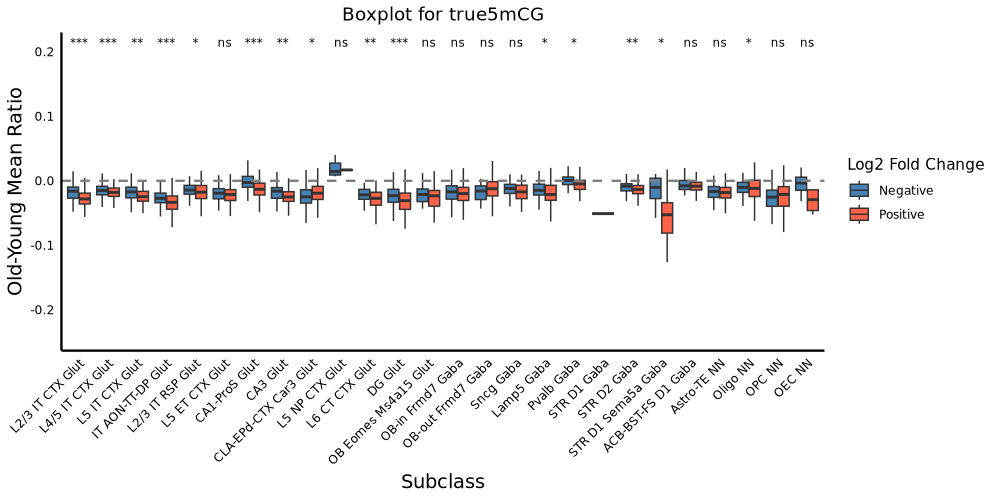

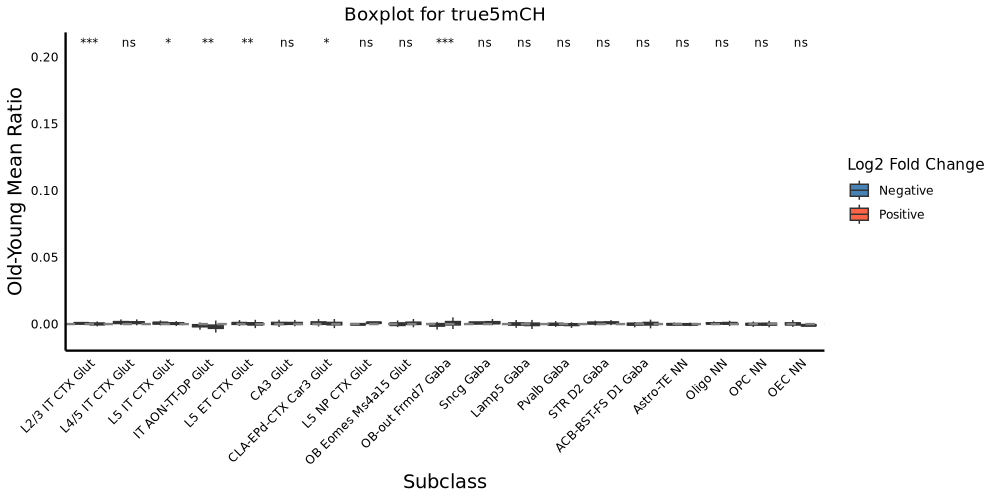

In [81]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 100)
boxplots_genebody

In [ ]:
pdf("../../../output/03-aging/06-ATAC/02-Genebody_boxplots_including_sig_true5mCG_update_t_test.pdf", width = 10, height = 10)
wrap_plots(boxplots_genebody[modifications], ncol = 1) %>%
  print()
dev.off()

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”


png 
  2

In [83]:
boxplots_genebody <- list()

In [84]:
for (mod in modifications) {
  current_data <- split_data_genebody[[mod]]

  merged_data <- current_data %>% 
    inner_join(old_young_gene_filter_genebody, by = c("subclass" = "class", "gene_id" = "genename"))
  
  if (nrow(merged_data) > 0) {
    merged_data <- merged_data %>%
      mutate(
        log2_sign = ifelse(log2FoldChange > 0, "Positive", "Negative"),
        subclass = factor(subclass, levels = subclass_order)
      )

    pvalues <- merged_data %>%
      group_by(subclass) %>%
      summarise(
        positive_count = sum(log2_sign == "Positive"),
        negative_count = sum(log2_sign == "Negative"),
        p_value = ifelse(positive_count > 1 & negative_count > 1,
                         wilcox.test(old_young_mean_ratio[log2_sign == "Positive"],
                                old_young_mean_ratio[log2_sign == "Negative"])$p.value,
                         NA_real_),
        .groups = "drop"
      ) %>%
      mutate(label = ifelse(p_value < 0.001, "***",
                            ifelse(p_value < 0.01, "**",
                                   ifelse(p_value < 0.05, "*", "ns"))))

    print(pvalues)

    p <- ggplot(merged_data, aes(x = subclass, y = old_young_mean_ratio, fill = log2_sign)) +
      geom_boxplot(outlier.shape = NA, position = position_dodge(width = 0.8)) +
      scale_fill_manual(values = c("Positive" = "tomato", "Negative" = "steelblue")) +
      geom_hline(yintercept = 0, linetype = "dashed", color = "grey50", size = 0.8) +
      geom_text(data = pvalues, aes(x = subclass, y = max(merged_data$old_young_mean_ratio, na.rm = TRUE) + 0.2, label = label),
                inherit.aes = FALSE, vjust = 0, size = 3) +
      labs(
        title = paste("Boxplot for", mod),
        x = "Subclass",
        y = "Old-Young Mean Ratio",
        fill = "Log2 Fold Change"
      ) +
      theme_minimal() +
      theme(
        plot.title = element_text(hjust = 0.5),
        axis.title = element_text(size = 14),
        axis.text.x = element_text(angle = 45, hjust = 1, color = "black"),
        axis.text.y = element_text(color = "black"),
        axis.line = element_line(color = "black", size = 0.8), 
        panel.grid = element_blank()
      )

    boxplots_genebody[[mod]] <- p
  } else {
    message(paste("No matching data for modification:", mod))
  }
}


# A tibble: 26 × 5
   subclass              positive_count negative_count  p_value label
   <fct>                          <int>          <int>    <dbl> <chr>
 1 L2/3 IT CTX Glut                 200             52 6.90e- 7 ***  
 2 L4/5 IT CTX Glut                 207            250 2.27e- 3 **   
 3 L5 IT CTX Glut                   155             55 2.47e- 3 **   
 4 IT AON-TT-DP Glut                353             71 6.51e- 4 ***  
 5 L2/3 IT RSP Glut                 177            158 6.22e- 2 ns   
 6 L5 ET CTX Glut                   160            121 2.11e- 1 ns   
 7 CA1-ProS Glut                    294            132 2.82e-13 ***  
 8 CA3 Glut                         134             95 7.09e- 4 ***  
 9 CLA-EPd-CTX Car3 Glut            155             97 7.01e- 3 **   
10 L5 NP CTX Glut                     2              7 5   e- 1 ns   
# ℹ 16 more rows
# A tibble: 19 × 5
   subclass              positive_count negative_count    p_value label
   <fct>                         

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”


$true5mCG

$true5mCH


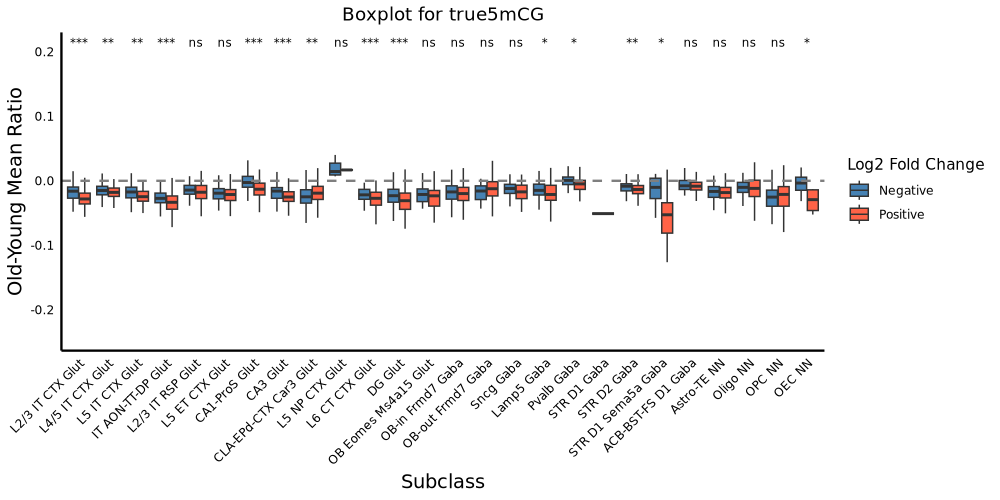

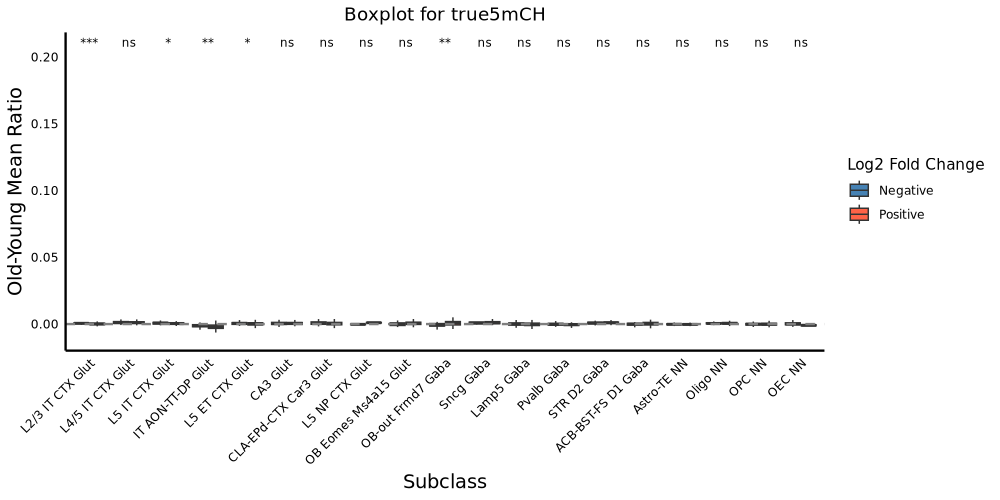

In [85]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 100)
boxplots_genebody

In [ ]:
pdf("../../../output/03-aging/06-ATAC/02-Genebody_boxplots_including_sig_true5mCG_update_wilcox_test.pdf", width = 10, height = 10)
wrap_plots(boxplots_genebody[modifications], ncol = 1) %>%
  print()
dev.off()

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”


png 
  2

In [124]:
boxplots_genebody <- list()

In [125]:
for (mod in modifications) {
  
  current_data <- split_data_genebody[[mod]]

  merged_data <- current_data %>%
    inner_join(old_young_gene_filter_genebody, 
               by = c("subclass" = "class", "gene_id" = "genename"))
  
  if (nrow(merged_data) > 0) {

    merged_data <- merged_data %>%
      mutate(
        log2_sign = ifelse(log2FoldChange > 0, "Positive", "Negative"),
        subclass = factor(subclass, levels = subclass_order)
      )

    p <- ggplot(merged_data, aes(x = subclass, y = old_young_mean_ratio, fill = log2_sign)) +
      geom_boxplot(outlier.shape = NA, position = position_dodge(width = 0.8)) +
      scale_fill_manual(values = c("Positive" = "tomato", "Negative" = "steelblue")) +
      geom_hline(yintercept = 0, linetype = "dashed", color = "grey50", size = 0.8) +
      labs(
        title = paste("Boxplot for", mod),
        x = "Subclass",
        y = "Old-Young Mean Ratio",
        fill = "Log2 Fold Change"
      ) +
      theme_minimal() +
      theme(
        plot.title = element_text(hjust = 0.5),
        axis.title = element_text(size = 14),
        axis.text.x = element_text(angle = 45, hjust = 1, color = "black"),
        axis.text.y = element_text(color = "black"),
        axis.line = element_line(color = "black", size = 0.8), 
        panel.grid = element_blank()
      )

    boxplots_genebody[[mod]] <- p
  } else {
    message(paste("No matching data for modification:", mod))
  }
}

$true5mCG

$true5mCH


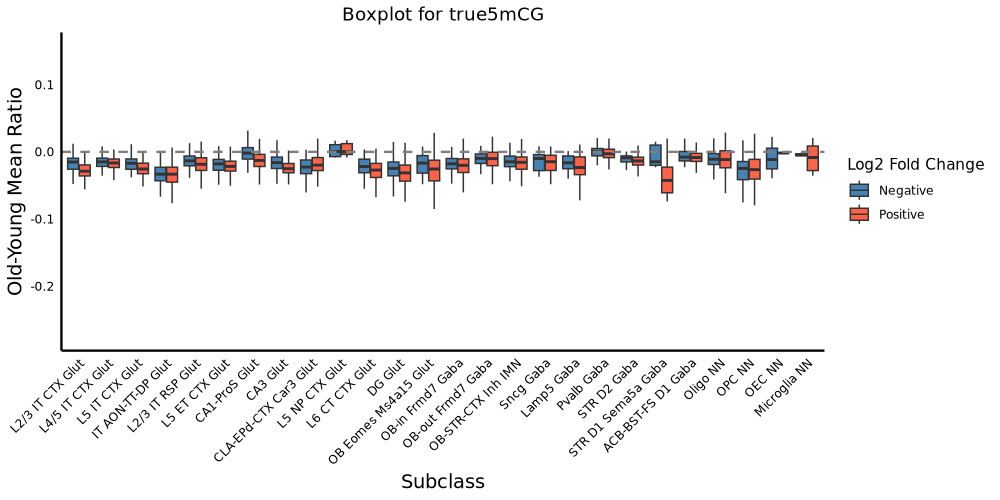

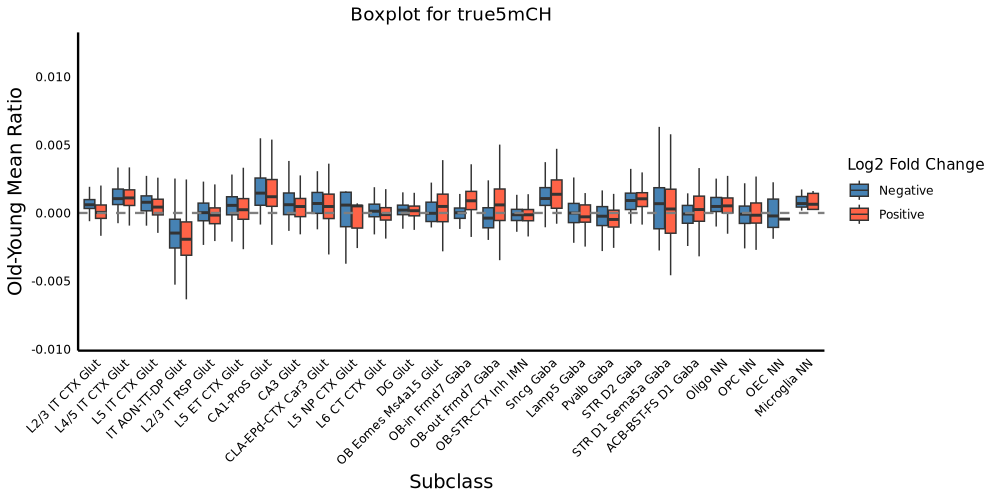

In [126]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 100)
boxplots_genebody

In [ ]:
pdf("../../../output/03-aging/06-ATAC/02-Genebody_boxplots_true5mCG.pdf", width = 10, height = 10)
wrap_plots(boxplots_genebody[modifications], ncol = 1) %>%
  print()
dev.off()

png 
  2

In [76]:
lineplots_genebody <- list()

In [77]:
for (mod in modifications) {

  current_data <- split_data_genebody[[mod]]

  merged_data <- current_data %>%
    inner_join(old_young_gene_filter_genebody, 
               by = c("subclass" = "class", "gene_id" = "genename"))
  
  if (nrow(merged_data) > 0) {

    merged_data <- merged_data %>%
      mutate(
        log2_sign = ifelse(log2FoldChange > 0, "Positive", "Negative"),
        subclass = factor(subclass, levels = subclass_order)
      )

    mean_data <- merged_data %>%
      group_by(subclass, log2_sign) %>%
      summarise(
        mean_value = mean(old_young_mean_ratio, na.rm = TRUE),
        .groups = "drop"
      )

    p <- ggplot(mean_data, aes(x = subclass, y = mean_value, color = log2_sign, group = log2_sign)) +
      geom_line(size = 1.2) +
      geom_point(size = 3) +
      scale_color_manual(values = c("Positive" = "tomato", "Negative" = "steelblue")) +
      labs(
        title = paste("Mean Old-Young Ratio for Positive and Negative Across Subclasses -", mod),
        x = "Subclass",
        y = "Mean Old-Young Mean Ratio",
        color = "Log2 Fold Change"
      ) +
      theme_minimal() +
      theme(
        plot.title = element_text(hjust = 0.5),
        axis.title = element_text(size = 14),
        axis.text.x = element_text(angle = 45, hjust = 1, color = "black"),
        axis.text.y = element_text(color = "black"),
        axis.line = element_line(color = "black", size = 0.8), 
        panel.grid = element_blank()
      )

    lineplots_genebody[[mod]] <- p
  } else {
    message(paste("No matching data for modification:", mod))
  }
}


$true5mCG

$true5mCH


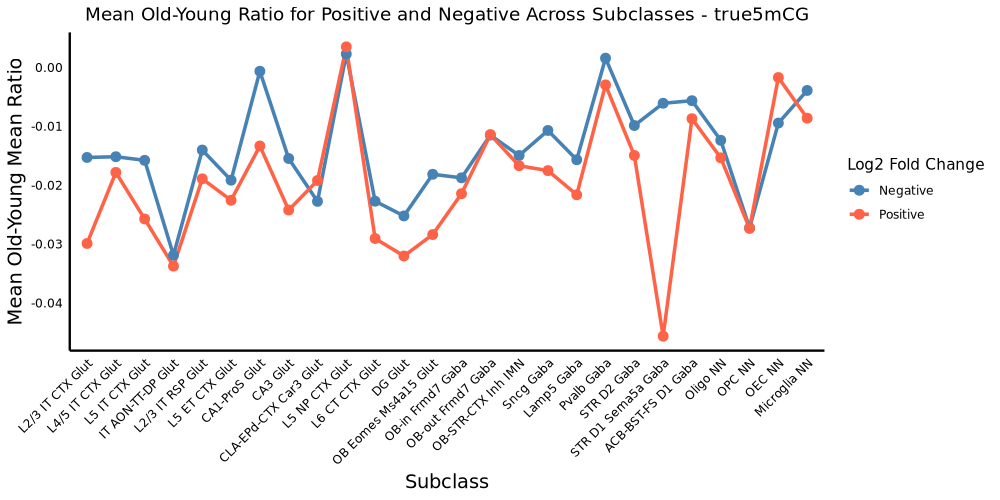

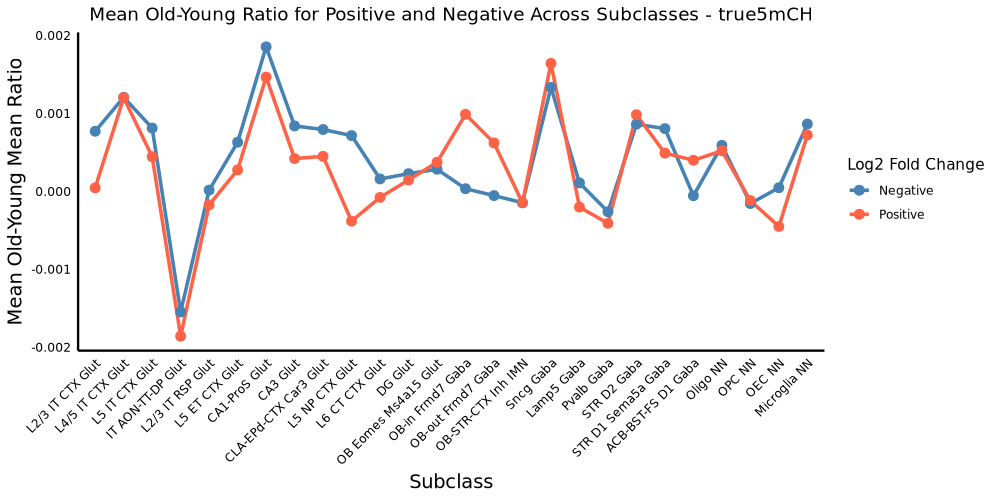

In [78]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 100)
lineplots_genebody

In [ ]:
pdf("../../../output/03-aging/06-ATAC/02-Genebody_lineplots_true5mCG.pdf", width = 10, height = 10)
wrap_plots(lineplots_genebody[modifications], ncol = 1) %>%
  print()
dev.off()

png 
  2

In [74]:
library(ggpubr)

Warning message:
“package ‘ggpubr’ was built under R version 4.3.3”


In [75]:
all_mean_data <- data.frame() 

In [76]:
for (mod in modifications) {

  current_data <- split_data_genebody[[mod]]

  merged_data <- current_data %>%
    inner_join(old_young_gene_filter_genebody, 
               by = c("subclass" = "class", "gene_id" = "genename"))
  
  if (nrow(merged_data) > 0) {

    merged_data <- merged_data %>%
      mutate(
        log2_sign = ifelse(log2FoldChange > 0, "Positive", "Negative"),
        subclass = factor(subclass, levels = subclass_order)
      )

    mean_data <- merged_data %>%
      group_by(subclass, log2_sign) %>%
      summarise(
        mean_value = mean(old_young_mean_ratio, na.rm = TRUE),
        .groups = "drop"
      ) %>%
      mutate(modification = mod)

    all_mean_data <- bind_rows(all_mean_data, mean_data)

  } else {
    message(paste("No matching data for modification:", mod))
  }
}

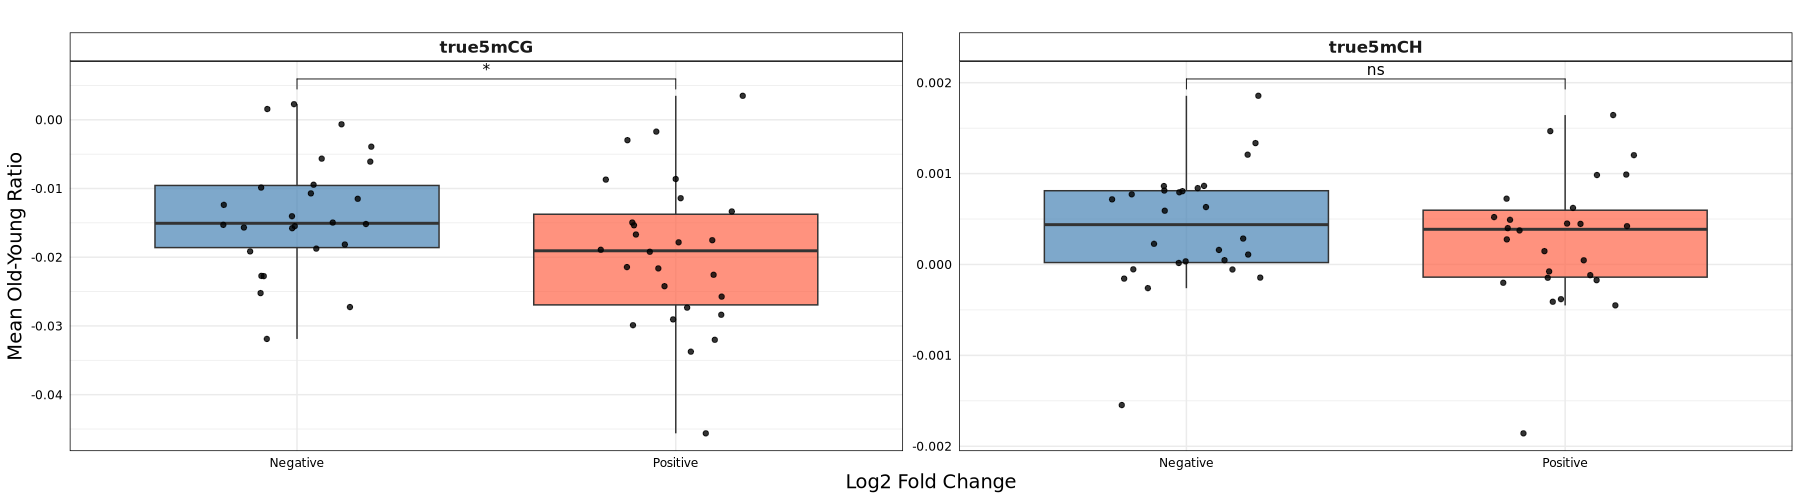

In [80]:
options(repr.plot.width = 18, repr.plot.height = 5, repr.plot.res = 100)
if (nrow(all_mean_data) > 0) {
  p <- ggplot(all_mean_data, aes(x = log2_sign, y = mean_value, fill = log2_sign)) +
    geom_boxplot(outlier.shape = NA, alpha = 0.7) + 
    geom_jitter(width = 0.2, size = 1.5, alpha = 0.8) + 
    scale_fill_manual(values = c("Positive" = "tomato", "Negative" = "steelblue")) +
    facet_wrap(~ modification, scales = "free_y", ncol = 2) +
    labs(
      title = "",
      x = "Log2 Fold Change",
      y = "Mean Old-Young Ratio"
    ) +
    theme_minimal() +
    theme(
      plot.title = element_text(hjust = 0.5),
      axis.title = element_text(size = 14),
      axis.text.x = element_text(angle = 0, hjust = 0.5, color = "black"),
      axis.text.y = element_text(color = "black"),
      legend.position = "none",
      panel.border = element_rect(color = "black", size = 0.5, fill = NA),
      strip.background = element_rect(color = "black", fill = "white"),
      strip.text = element_text(size = 12, face = "bold")
    ) +
    stat_compare_means(
      method = "wilcox.test",
      label = "p.signif",
      comparisons = list(c("Positive", "Negative"))
    )
  
  print(p)
} else {
  message("No data available for plotting.")
}

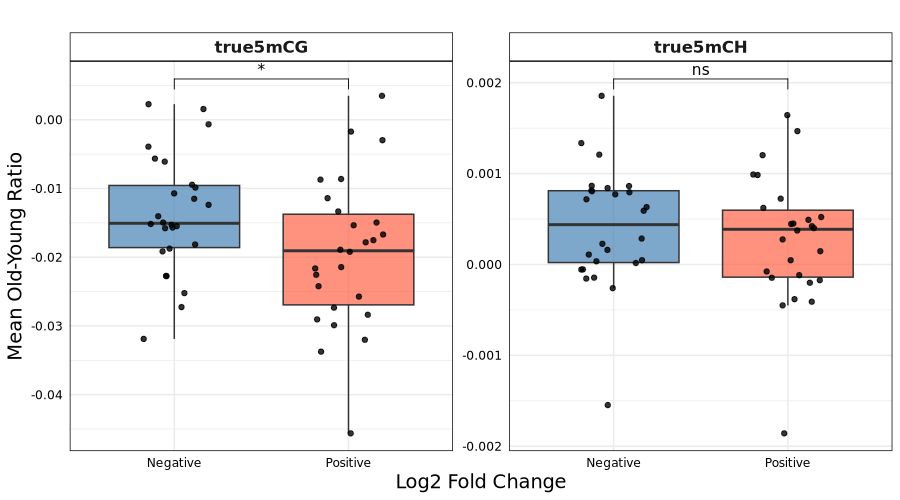

In [81]:
options(repr.plot.width = 9, repr.plot.height = 5, repr.plot.res = 100)
p

In [ ]:
pdf("../../../output/03-aging/06-ATAC/02-Genebody_boxplot_true5mC_mean.pdf", width = 9, height = 5)
p
dev.off()

png 
  2